In [490]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib inline

Analyze the assignment

In [491]:
# Test case
res = 90
procs = 144
case = f"c{res}_p{procs}"

reassign_types = [
    "greedy",
    "nearest_greedy",
    "bilinear_greedy",
    "bicubic_greedy",
]
reassgins = {}

In [492]:
# Load the CSV files
og_assign = pd.read_csv(f"test/og_assignments/{case}.csv", index_col=0)
for sim_type in reassign_types:
    file_path = f"test/{sim_type}/{case}/assignment.csv"
    reassgins[sim_type] = pd.read_csv(file_path, index_col=0)

# Trim the original dataframe to match the upscaled intervals
upscaled_df = reassgins["bilinear_greedy"]
original_df = reassgins["greedy"]
original_df = original_df[upscaled_df.columns]

# Rename the columns to match the upscaled intervals
nintervals = len(upscaled_df.columns)
intervals = range(nintervals)
upscaled_df.columns = intervals
original_df.columns = intervals

In [493]:
# Track the target processor the original and reassignment decide to assign for each processor at each interval
# Also track how many times it is assigned to that processor
# Assuming there is up to one target processor per processor at each interval
def count_assignments(
    assign: pd.DataFrame, og_assign: pd.DataFrame, procs: int
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Count the number of assignments for each processor at each interval.
    """
    samples, intervals = assign.shape
    counts = np.zeros((procs, intervals), dtype=int)
    targets = -np.ones((procs, intervals), dtype=int)

    # Expand original assignments to match shape of assign
    og_expanded = np.tile(og_assign.values, (1, intervals))

    # Mask where assignments differ
    mask = assign.values != og_expanded

    # Get processor indices and interval indices where reassignment occurred
    reassigned_proc = assign.values[mask]
    original_proc = og_expanded[mask]
    interval_idx = np.tile(np.arange(intervals), samples)[mask.ravel()]

    # Count assignments and set targets
    for proc, orig, idx in zip(reassigned_proc, original_proc, interval_idx):
        counts[proc, idx] += 1
        targets[proc, idx] = orig

    return pd.DataFrame(
        counts, index=range(procs), columns=assign.columns
    ), pd.DataFrame(targets, index=range(procs), columns=assign.columns)

In [494]:
# Count it for greedy heuristic on both the original and upscaled workloads
og_counts, og_targets = count_assignments(original_df, og_assign, procs)

# Print the first interval of the counts and targets
print("Original workload counts:", og_counts.iloc[:, 0].values)
print("Original workload targets:", og_targets.iloc[:, 0].values)

Original workload counts: [ 37  62  70   3  74  83  89  64  59  58  81   8  61  65  18  48  48  55
  95  25  82  94   2  33  87  72  11 101  62  68  55  68  29  85  83  74
   2   3 112  79  45  62  82  86   2  91  70  72   8  87  43  61  13  58
  25  44  33  20  33  10   3  20  48  12  39  31  11  44  71  58   1  11
  60  60  44  54  17  11  29  18   1  72   2  37  45  84  40  36  63  22
   3  21  39  25  36  50  60  43  59  33  54   8  10  72  48  59  65 118
  85  95  94  25 124  62   8  13  22  21  60  31  59  40  63  89  84  58
  62  81  64  86 124  44  12 118 112  17  50 101  91  71  58  62  58  79]
Original workload targets: [ 83 126  46  60  35  34 123 128 120  69 127 101  51 106  79  62 104  30
 109 111  42 110  82  56  49 103  71 137 113  31  17  29  78 108   5   4
  44  90 134 143  84 141  20 129  36 138   2  81 114  24  97  12 115 142
  93 131  23  61  99 102   3  57  15 132  92 119  77  74 139   9  80  26
 118  96  67 100 135  66  32  14  70  47  22   0  40 124 121  94 122 1

In [495]:
upscaled_counts, upscaled_targets = count_assignments(upscaled_df, og_assign, procs)

print("Upscaled workload counts:", upscaled_counts.iloc[:, 0].values)
print("Upscaled workload targets:", upscaled_targets.iloc[:, 0].values)

Upscaled workload counts: [ 27  61  65  26  49  93  99  53  52  34  93  25  40  64  19  58  38  92
  60  20  63  95  20  32  78  53  18 103  80  73  59  73  10  80  91  80
   9   2 112  92  65  63  89  99  14  95  76  80  10  93  45  64  32  68
  26  40  53   7  45   1  21  46  50  25  50  24  18  71  78  49  14  76
  68  74  53  61  14   7  38  31  26  91   9  30  87 101  74  19  71  68
  26  19  83  68  64  53  89  59  69  27  58  31  19  69  46  52  60 125
  93 101 101  34 126  71   9   2  32   9  68  30  59  32  68  93  83  64
  71  87  71  21 126  24   1 112 125  14  32 103 101  93  59  71  32  53]
Upscaled workload targets: [ 99  75  40  80  69  49  43  56 105 111 123  63  55 125  91 100  78  39
 106  22  41  45  19  52  68  74  66 137  35  31  97  29  48  47  81  28
 117 115 133  17   2  20  96   6  70  21  71  33  32   5  58  94  23  89
  90  12   7  77  50 132 129 104  64  11  62 131  26 128  24   4  44  46
 118  86  25   1 135  57  16 101   3  34 114 119 127 110  73 102 113  

In [496]:
# Tally for each interval, how many times does the upscaled workload assigns to a different processor than the original workload
target_diff = upscaled_targets != og_targets
target_diff_count = target_diff.sum(axis=0)

print("Target difference counts:", target_diff_count.values)


Target difference counts: [134 126 136 130 124 124 122 130 120 136 130 122 132 132 126 134 134 128
 132 136 128 136 130 128 128 134 126 122 136 128 130 132 128 134 138 134
 132 134 136 126 122 126 126 128 124 134 126 138 132 136 134 136 132 130
 132 128 132 136 136 128 132 136 124 134 132 132 132 132 138 128 126 124]


Compare the workload
Hypothesis: the highest workload and lowest workload processors are predicted correctly.

In [497]:
# Read the workload data
workload_df = pd.read_csv(f"test/workloads/c{res}.csv", index_col=0, header=0)

nearest_workload_df = pd.read_csv(f"test/workloads/nearest_c24_to_c{res}.csv", index_col=0, header=0)
bilinear_workload_df = pd.read_csv(f"test/workloads/bilinear_c24_to_c{res}.csv", index_col=0, header=0)
bicubic_workload_df = pd.read_csv(f"test/workloads/bicubic_c24_to_c{res}.csv", index_col=0, header=0)

# Trim the original workload to match the upscaled intervals
workload_df = workload_df[bilinear_workload_df.columns]

In [498]:
# Compute the workload for each processor at each interval using the original assignments
def compute_workload(
    workload_df: pd.DataFrame, og_assign: pd.DataFrame, procs: int
) -> pd.DataFrame:
    """
    Compute the workload for each processor at each interval.
    """
    _, intervals = workload_df.shape
    workload = np.zeros((procs, intervals), dtype=float)
    assigned_procs = og_assign.values.flatten()

    for interval in range(intervals):
        np.add.at(
            workload[:, interval], assigned_procs, workload_df.values[:, interval]
        )

    return pd.DataFrame(workload, index=range(procs), columns=workload_df.columns)

In [499]:
# Compute the workload for the original workload df
og_workload = compute_workload(workload_df, og_assign, procs)

og_max_indices = og_workload.idxmax(axis=0)
rows = og_max_indices.values
cols = np.arange(len(og_workload.columns))
og_max_values = og_workload.values[rows, cols]

In [500]:
# Compute the workload for the bilinear workload df
bilinear_workload = compute_workload(bilinear_workload_df, og_assign, procs)

bilinear_max_indices = bilinear_workload.idxmax(axis=0)
rows = bilinear_max_indices.values
cols = np.arange(len(bilinear_workload.columns))
bilinear_max_values = bilinear_workload.values[rows, cols]

In [501]:
# Check how many times the upscaled workload predicts the max workload processor correctly
correct_predictions = bilinear_max_indices == og_max_indices
correct_predictions_count = correct_predictions.sum()
print("Correct predictions count:", correct_predictions_count)

# For each of those correct predictions, check how far off the predicted workload is from the actual workload
ratios = bilinear_max_values[correct_predictions] / og_max_values[correct_predictions]

# Compute summary statistics for the ratios
median_ratio = np.nanmedian(ratios)
geo_mean_ratio = np.exp(np.nanmean(np.log(ratios[ratios > 0])))
within_1_percent = np.mean((ratios >= 0.99) & (ratios <= 1.01)) * 100
mape = np.mean(np.abs(1 - ratios)) * 100

# Repeat the computation but including all predictions
ratios_all = bilinear_max_values / og_max_values

# Compute summary statistics for the ratios
median_ratio_all = np.nanmedian(ratios_all)
geo_mean_ratio_all = np.exp(np.nanmean(np.log(ratios_all[ratios_all > 0])))
within_1_percent_all = np.mean((ratios_all >= 0.99) & (ratios_all <= 1.01)) * 100
mape_all = np.mean(np.abs(1 - ratios_all)) * 100

# Create summary table
summary_table = pd.DataFrame(
    {
        "Median Ratio": [median_ratio, median_ratio_all],
        "Geometric Mean Ratio": [geo_mean_ratio, geo_mean_ratio_all],
        "% Within 1%": [within_1_percent, within_1_percent_all],
        "MAPE (%)": [mape, mape_all],
    },
    index=["Correct", "All"],
)

print(summary_table)

Correct predictions count: 65
         Median Ratio  Geometric Mean Ratio  % Within 1%  MAPE (%)
Correct      1.003539              1.004642    69.230769  0.830787
All          1.004387              1.004995    66.666667  0.839026


In [502]:
# Absolute difference
abs_diff_correct = np.abs(
    bilinear_max_values[correct_predictions] - og_max_values[correct_predictions]
)
abs_diff_all = np.abs(bilinear_max_values - og_max_values)


abs_diff_table = pd.DataFrame(
    {
        "mean": [np.mean(abs_diff_correct), np.mean(abs_diff_all)],
        "std": [np.std(abs_diff_correct), np.std(abs_diff_all)],
        "min": [np.min(abs_diff_correct), np.min(abs_diff_all)],
        "max": [np.max(abs_diff_correct), np.max(abs_diff_all)],
        "median": [np.median(abs_diff_correct), np.median(abs_diff_all)],
    },
    index=["Correct", "All"],
)
print(abs_diff_table)

                mean          std        min          max       median
Correct  1694.690974  1463.188372  86.687778  7160.313333  1295.996667
All      1712.500185  1442.100731  86.687778  7160.313333  1335.817222


In [503]:
# Absolute ratio deviation
ratios_correct = (
    bilinear_max_values[correct_predictions] / og_max_values[correct_predictions]
)
ratios_all = bilinear_max_values / og_max_values
abs_ratio_dev_correct = np.abs(ratios_correct - 1)
abs_ratio_dev_all = np.abs(ratios_all - 1)

abs_ratio_table = pd.DataFrame(
    {
        "mean": [
            abs_ratio_dev_correct.mean(),
            abs_ratio_dev_all.mean(),
        ],
        "std": [
            np.std(abs_ratio_dev_correct),
            np.std(abs_ratio_dev_all),
        ],
        "min": [
            np.min(abs_ratio_dev_correct),
            np.min(abs_ratio_dev_all),
        ],
        "median": [
            np.median(abs_ratio_dev_correct),
            np.median(abs_ratio_dev_all),
        ],
        "max": [
            np.max(abs_ratio_dev_correct),
            np.max(abs_ratio_dev_all),
        ],
    },
    index=["Correct", "All"],
)
print(abs_ratio_table)

             mean       std       min    median       max
Correct  0.008308  0.007296  0.000417  0.006486  0.038145
All      0.008390  0.007166  0.000417  0.006606  0.038145


In [504]:
# Now rather than just comparing the max workload per processor, compare the entire workload
# Compute the absolute difference between the bilinear and original workloads, and summarize the results
abs_diff_workload = np.abs(bilinear_workload.values - og_workload.values)
abs_diff_workload_df = pd.DataFrame(
    abs_diff_workload, index=range(procs), columns=workload_df.columns
)
abs_diff_workload_summary = abs_diff_workload_df.describe().T
# Drop the count, 25%, and 75% columns, and rename the 50% column to median
abs_diff_workload_summary.drop(columns=["count", "25%", "75%"], inplace=True)
abs_diff_workload_summary.rename(
    columns={
        "50%": "median",
    },
    inplace=True,
)
print(abs_diff_workload_summary)

                       mean          std        min       median           max
20190701_0000z  4911.234390  2997.661155  11.502222  4346.280556  14075.013333
20190701_0020z  4871.771466  3012.088492  32.274444  4551.140000  14890.192222
20190701_0040z  3031.232361  2533.000874  50.570000  2491.932222  14714.891111
20190701_0100z  3063.774198  2363.371291  29.444444  2652.506111  12716.384444
20190701_0120z  3300.729390  2325.043131  98.961111  2977.100000  13505.756667
...                     ...          ...        ...          ...           ...
20190701_2220z  3475.814090  2987.293541   2.587778  2716.693333  20608.902222
20190701_2240z  3373.095085  3000.043849  86.104444  2496.382778  21458.856667
20190701_2300z  3375.712878  3009.791851  38.675556  2573.554444  20175.810000
20190701_2320z  3275.002562  3017.453276   5.373333  2525.634444  20362.198889
20190701_2340z  3324.364560  3053.190765  45.093333  2346.868889  20119.218889

[72 rows x 5 columns]


In [505]:
# Repeat the same for the ratios
ratios_workload = bilinear_workload.values / og_workload.values
ratios_workload_df = pd.DataFrame(
    ratios_workload, index=range(procs), columns=workload_df.columns
)
ratios_workload_summary = ratios_workload_df.describe().T
# Drop the count, 25%, and 75% columns, and rename the 50% column to median
ratios_workload_summary.drop(columns=["count", "25%", "75%"], inplace=True)
ratios_workload_summary.rename(
    columns={
        "50%": "median",
    },
    inplace=True,
)
print(ratios_workload_summary)

                    mean       std       min    median       max
20190701_0000z  1.018866  0.085174  0.757616  1.035317  1.204917
20190701_0020z  1.089832  0.069477  0.988029  1.081065  1.327470
20190701_0040z  1.052252  0.055540  0.941717  1.036834  1.226242
20190701_0100z  1.054223  0.052510  0.947547  1.047289  1.217482
20190701_0120z  1.059014  0.051898  0.949449  1.055117  1.214367
...                  ...       ...       ...       ...       ...
20190701_2220z  1.057074  0.059178  0.936240  1.041718  1.275705
20190701_2240z  1.055740  0.059451  0.949362  1.042762  1.320447
20190701_2300z  1.055610  0.059948  0.944865  1.042341  1.317088
20190701_2320z  1.053827  0.059207  0.960688  1.040775  1.287580
20190701_2340z  1.054268  0.061452  0.936932  1.034334  1.326572

[72 rows x 5 columns]


In [506]:
# And absolute ratio deviation
abs_ratio_dev_workload = np.abs(ratios_workload - 1)
abs_ratio_dev_workload_df = pd.DataFrame(
    abs_ratio_dev_workload, index=range(procs), columns=workload_df.columns
)
abs_ratio_dev_workload_summary = abs_ratio_dev_workload_df.describe().T
# Drop the count, 25%, and 75% columns, and rename the 50% column to median
abs_ratio_dev_workload_summary.drop(columns=["count", "25%", "75%"], inplace=True)
abs_ratio_dev_workload_summary.rename(
    columns={
        "50%": "median",
    },
    inplace=True,
)
print(abs_ratio_dev_workload_summary)

                    mean       std       min    median       max
20190701_0000z  0.070244  0.051424  0.000102  0.060038  0.242384
20190701_0020z  0.090378  0.068761  0.000350  0.081065  0.327470
20190701_0040z  0.055945  0.051790  0.000335  0.037848  0.226242
20190701_0100z  0.056649  0.049865  0.000324  0.047568  0.217482
20190701_0120z  0.061453  0.048965  0.000505  0.055117  0.214367
...                  ...       ...       ...       ...       ...
20190701_2220z  0.060193  0.055979  0.000053  0.044051  0.275705
20190701_2240z  0.058867  0.056335  0.000466  0.043020  0.320447
20190701_2300z  0.059258  0.056319  0.000359  0.044961  0.317088
20190701_2320z  0.057588  0.055529  0.000029  0.040804  0.287580
20190701_2340z  0.058705  0.057198  0.000321  0.035717  0.326572

[72 rows x 5 columns]


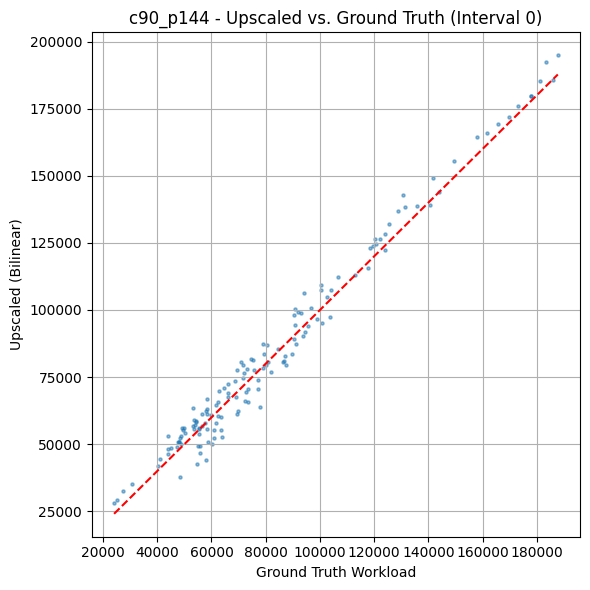

In [507]:
import matplotlib.pyplot as plt

# Plot a scatter plot for processor workload between the original and bilinear upscaled workloads
interval = 0  # start with a representative interval
x = og_workload.iloc[:, interval].values
y = bilinear_workload.iloc[:, interval].values

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=5)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color="red", linestyle="--")
plt.xlabel("Ground Truth Workload")
plt.ylabel("Upscaled (Bilinear)")
plt.title(f"{case} - Upscaled vs. Ground Truth (Interval {interval})")
plt.grid(True)
plt.tight_layout()
plt.show()

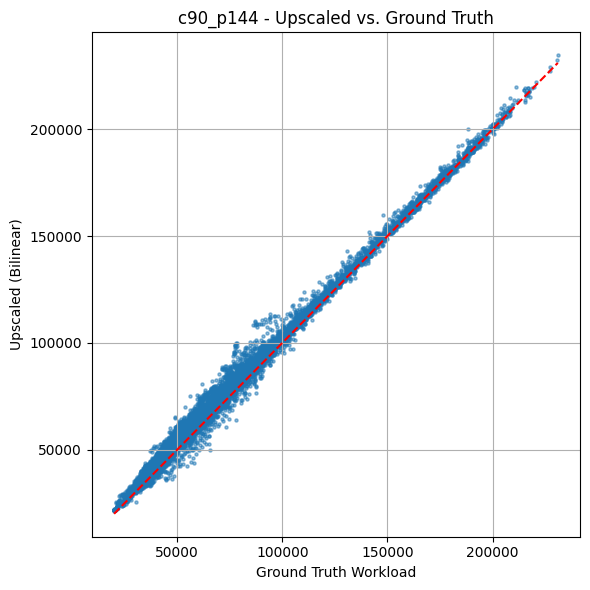

In [508]:
# Repeat the plot for all intervals
x = og_workload.values.flatten()
y = bilinear_workload.values.flatten()

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=5)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color="red", linestyle="--")
plt.xlabel("Ground Truth Workload")
plt.ylabel("Upscaled (Bilinear)")
plt.title(f"{case} - Upscaled vs. Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

In [513]:
from scipy.stats import spearmanr


# # Compute the spear correlation for each processor and interval
# def compute_spearman_correlation(
#     og_workload_df: pd.DataFrame, workload_df: pd.DataFrame, og_assign: pd.DataFrame
# ) -> pd.DataFrame:
#     """
#     Compute the Spearman correlation
#     """
#     samples, intervals = workload_df.shape
#     procs = og_assign.max().max() + 1
#     print(f"Samples: {samples}, Intervals: {intervals}, Procs: {procs}")

#     correlations = np.zeros((intervals, procs), dtype=float)

#     # Compute the Spearman correlation
#     for interval in range(intervals):
#         # Gather the workload for each processor at each interval
#         og_workloads = [[] for _ in range(procs)]
#         workloads = [[] for _ in range(procs)]
#         for sample in range(samples):
#             og_workloads[og_assign.iloc[sample, 0]].append(
#                 og_workload_df.iloc[sample, interval]
#             )
#             workloads[og_assign.iloc[sample, 0]].append(
#                 workload_df.iloc[sample, interval]
#             )
#         for proc in range(procs):
#             corr, _ = spearmanr(og_workloads[proc], workloads[proc])
#             correlations[interval, proc] = corr
#     return pd.DataFrame(correlations)


def compute_spearman_correlation(
    og_workload_df: pd.DataFrame, workload_df: pd.DataFrame, og_assign: pd.DataFrame
) -> pd.DataFrame:
    """
    Compute Spearman correlation between ground truth and predicted workload,
    grouped by processor and interval.
    Returns a DataFrame of shape (intervals, procs).
    """
    _, intervals = workload_df.shape
    procs = int(og_assign.values.max()) + 1
    assignments = og_assign.values.flatten()

    correlations = np.full((intervals, procs), np.nan, dtype=float)

    # Pre-convert to NumPy arrays for performance
    og_values = og_workload_df.values
    pred_values = workload_df.values

    for proc in range(procs):
        mask = assignments == proc
        if np.sum(mask) < 2:
            continue  # Not enough data to compute correlation
        og_proc = og_values[mask]
        pred_proc = pred_values[mask]
        for t in range(intervals):
            corr, _ = spearmanr(og_proc[:, t], pred_proc[:, t])
            correlations[t, proc] = corr

    return pd.DataFrame(correlations, columns=[f"Proc {p}" for p in range(procs)])


# Compute the Spearman correlation for the bilinear workload
nearest_spearman = compute_spearman_correlation(
    workload_df, nearest_workload_df, og_assign
)
bilinear_spearman = compute_spearman_correlation(
    workload_df, bilinear_workload_df, og_assign
)
bicubic_spearman = compute_spearman_correlation(
    workload_df, bicubic_workload_df, og_assign
)
print(bilinear_spearman)

      Proc 0    Proc 1    Proc 2    Proc 3    Proc 4    Proc 5    Proc 6  \
0   0.585895  0.765762  0.792463  0.427492  0.749603  0.832021  0.547418   
1   0.484769  0.801252  0.712863  0.529135  0.580904  0.837221  0.743951   
2   0.603199  0.843509  0.801727  0.604353  0.687743  0.868877  0.758685   
3   0.575384  0.828993  0.799889  0.620966  0.659974  0.885092  0.757914   
4   0.551699  0.816267  0.846274  0.653421  0.671319  0.869704  0.808986   
..       ...       ...       ...       ...       ...       ...       ...   
67  0.636070  0.808973  0.832008  0.565988  0.521921  0.776523  0.788658   
68  0.662198  0.785560  0.830200  0.571188  0.569521  0.769089  0.756269   
69  0.651868  0.751727  0.836019  0.617248  0.610103  0.767313  0.796548   
70  0.655913  0.693510  0.820557  0.593814  0.672686  0.772656  0.784694   
71  0.654072  0.676208  0.838772  0.620896  0.698064  0.788490  0.812955   

      Proc 7    Proc 8    Proc 9  ...  Proc 134  Proc 135  Proc 136  Proc 137  \
0   0.

In [ ]:
# Summarize the Spearman correlation
nearest_spearman_summary = pd.DataFrame(nearest_spearman.values.flatten()).describe()
nearest_spearman_summary.drop(index=["count", "25%", "75%"], inplace=True)
nearest_spearman_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

bilinear_spearman_summary = pd.DataFrame(bilinear_spearman.values.flatten()).describe()
bilinear_spearman_summary.drop(index=["count", "25%", "75%"], inplace=True)
bilinear_spearman_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

bicubic_spearman_summary = pd.DataFrame(bicubic_spearman.values.flatten()).describe()
bicubic_spearman_summary.drop(index=["count", "25%", "75%"], inplace=True)
bicubic_spearman_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

# Combine the summaries into a single DataFrame
spearman_summary = pd.concat(
    [nearest_spearman_summary, bilinear_spearman_summary, bicubic_spearman_summary],
    axis=1,
)
spearman_summary.columns = ["nearest", "bilinear", "bicubic"]
# Print the summary statistics
print(spearman_summary)

         nearest  bilinear   bicubic
mean    0.851661  0.877966  0.875061
std     0.099106  0.088746  0.090964
min     0.294606  0.297611  0.270598
median  0.875105  0.900927  0.898099
max     0.987500  0.995791  0.996398


In [ ]:
# Compute the spearman correlation for each interval
def compute_spearman_correlation(
    og_workload: pd.DataFrame, pred_workload: pd.DataFrame
) -> pd.Series:
    """
    Compute the spearman correlation for each interval.
    """
    correlations = [
        spearmanr(og_workload.iloc[:, i].values, pred_workload.iloc[:, i].values)[0]
        for i in range(og_workload.shape[1])
    ]
    return pd.Series(correlations)

# Compute the spearman correlation
nearest_correlation = compute_spearman_correlation(workload_df, nearest_workload_df)
bilinear_correlation = compute_spearman_correlation(workload_df, bilinear_workload_df)
bicubic_correlation = compute_spearman_correlation(workload_df, bicubic_workload_df)

# Summary statistics
nearest_correlation_summary = nearest_correlation.describe()
nearest_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
nearest_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)
bilinear_correlation_summary = bilinear_correlation.describe()
bilinear_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
bilinear_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)
bicubic_correlation_summary = bicubic_correlation.describe()
bicubic_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
bicubic_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

# Combine all summaries into a single table
correlation_table = pd.DataFrame(
    {
        "nearest": nearest_correlation_summary,
        "bilinear": bilinear_correlation_summary,
        "bicubic": bicubic_correlation_summary,
    }
)

# Print the table with comma as separator
print(correlation_table.to_string(index=True, header=True, float_format="%.3f"))

        nearest  bilinear  bicubic
mean      0.938     0.950    0.949
std       0.011     0.010    0.011
min       0.895     0.913    0.910
median    0.943     0.955    0.955
max       0.950     0.961    0.961


In [ ]:
from scipy.stats import pearsonr

# Compute the pearson correlation for each interval
def compute_pearson_correlation(
    og_workload: pd.DataFrame, pred_workload: pd.DataFrame
) -> pd.Series:
    """
    Compute the pearson correlation for each interval.
    """
    correlations = [
        pearsonr(og_workload.iloc[:, i].values, pred_workload.iloc[:, i].values)[0]
        for i in range(og_workload.shape[1])
    ]
    return pd.Series(correlations)

# Compute the pearson correlation
nearest_pearson_correlation = compute_pearson_correlation(workload_df, nearest_workload_df)
bilinear_pearson_correlation = compute_pearson_correlation(workload_df, bilinear_workload_df)
bicubic_pearson_correlation = compute_pearson_correlation(workload_df, bicubic_workload_df)

# Summary statistics
nearest_pearson_correlation_summary = nearest_pearson_correlation.describe()
nearest_pearson_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
nearest_pearson_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

bilinear_pearson_correlation_summary = bilinear_pearson_correlation.describe()
bilinear_pearson_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
bilinear_pearson_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

bicubic_pearson_correlation_summary = bicubic_pearson_correlation.describe()
bicubic_pearson_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
bicubic_pearson_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

# Combine all summaries into a single table
pearson_correlation_table = pd.DataFrame(
    {
        "nearest": nearest_pearson_correlation_summary,
        "bilinear": bilinear_pearson_correlation_summary,
        "bicubic": bicubic_pearson_correlation_summary,
    }
)
# Print the table with comma as separator
print(pearson_correlation_table.to_string(index=True, header=True, float_format="%.3f"))

        nearest  bilinear  bicubic
mean      0.972     0.983    0.983
std       0.006     0.005    0.005
min       0.945     0.955    0.954
median    0.973     0.984    0.985
max       0.980     0.988    0.989


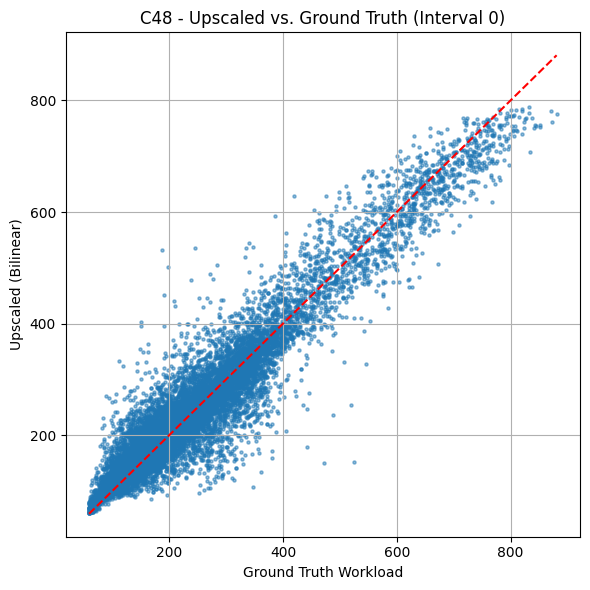

In [ ]:
interval = 0  # start with a representative interval
x = workload_df.iloc[:, interval].array
y = bilinear_workload_df.iloc[:, interval].array

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=5)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color="red", linestyle="--")
plt.xlabel("Ground Truth Workload")
plt.ylabel("Upscaled (Bilinear)")
plt.title(f"C{res} - Upscaled vs. Ground Truth (Interval {interval})")
plt.grid(True)
plt.tight_layout()
plt.show()

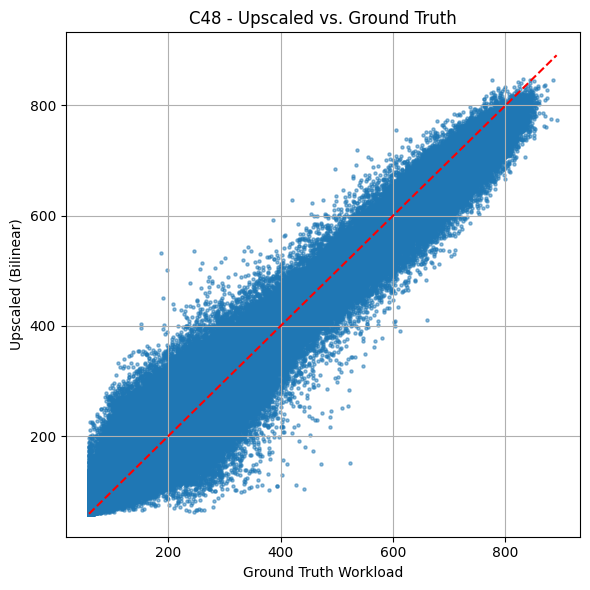

In [ ]:
# Repeat it but using data from all intervals
x = workload_df.values.flatten()
y = bilinear_workload_df.values.flatten()
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=5)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color="red", linestyle="--")
plt.xlabel("Ground Truth Workload")
plt.ylabel("Upscaled (Bilinear)")
plt.title(f"C{res} - Upscaled vs. Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

Compare the simulated workspan

In [ ]:
# Read all the simulation data
simulation_types = ["original", "greedy", "nearest_greedy", "bilinear_greedy", "bicubic_greedy"]
simulations = {}

for sim_type in simulation_types:
    if sim_type == "original":
        file_path = f"test/og_assignments/{case}_simulation.csv"
    else:
        file_path = f"test/{sim_type}/{case}/simulation.csv"
    simulations[sim_type] = pd.read_csv(file_path)

In [ ]:
# Generate an animation showing the workload distribution for all the simulation types
fig, ax = plt.subplots(figsize=(160, 6))
bar_width = 0.15
bars = []

# Exclude 'Interval' column and the last 4 Max,Mean,SD,CV columns
ylim = max(simulations[simulation_types[i]].iloc[:, 1:-4].max().max() * 1.1 for i in range(len(simulation_types)))
xlabels = simulations[simulation_types[0]].columns[1:-4]
x = np.arange(len(xlabels))

def init():
    ax.clear()
    ax.margins(x=0)
    ax.set_ylim(0, ylim)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=90)
    ax.set_ylabel("Workload")
    ax.set_title("Workload Distribution per Processor")
    fig.tight_layout()
    return bars

def update(frame):
    ax.clear()
    ax.margins(x=0)
    for i, sim_type in enumerate(simulation_types):
        sim_data = simulations[sim_type]
        workloads = sim_data.iloc[frame, 1:-4]
        bar = ax.bar(x + i * bar_width, workloads, bar_width, label=sim_type)
        bars.append(bar)
    # Plot a dotted reference line for the mean workload
    mean = simulations[simulation_types[0]].iloc[frame, -3]
    ax.axhline(mean, color="red", linestyle="--", label="Mean Workload")

    ax.set_ylim(0, ylim)
    ax.set_xticks(x + bar_width * (len(simulation_types)-1)/2)
    ax.set_xticklabels(xlabels, rotation=90)
    ax.set_ylabel("Workload")
    ax.set_title(f"Workload Distribution per Processor (Interval {frame})")
    ax.legend(
        loc="upper right",
        title="Simulation Type",
        fontsize="small",
    )
    fig.tight_layout()
    return bars

ani = FuncAnimation(
    fig,
    update,
    frames=range(len(simulations[simulation_types[0]])),
    init_func=init,
    blit=False,
)

ani.save(f"{case}_anim.gif", writer="imagemagick")